In [168]:
import pandas as pd

path = '/Users/petertroitsky/Desktop/application_train.csv'

data = pd.read_csv(path)

print('Форма:', data.shape)
print('\nИнформация:')
print(data.info())

print('\nПризнаки:')
print(data.columns)

missing = (
    data.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print('\nПропуски:')
print(missing.head(9))

Форма: (307511, 122)

Информация:
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB
None

Признаки:
Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=122)

Пропуски:
COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
F

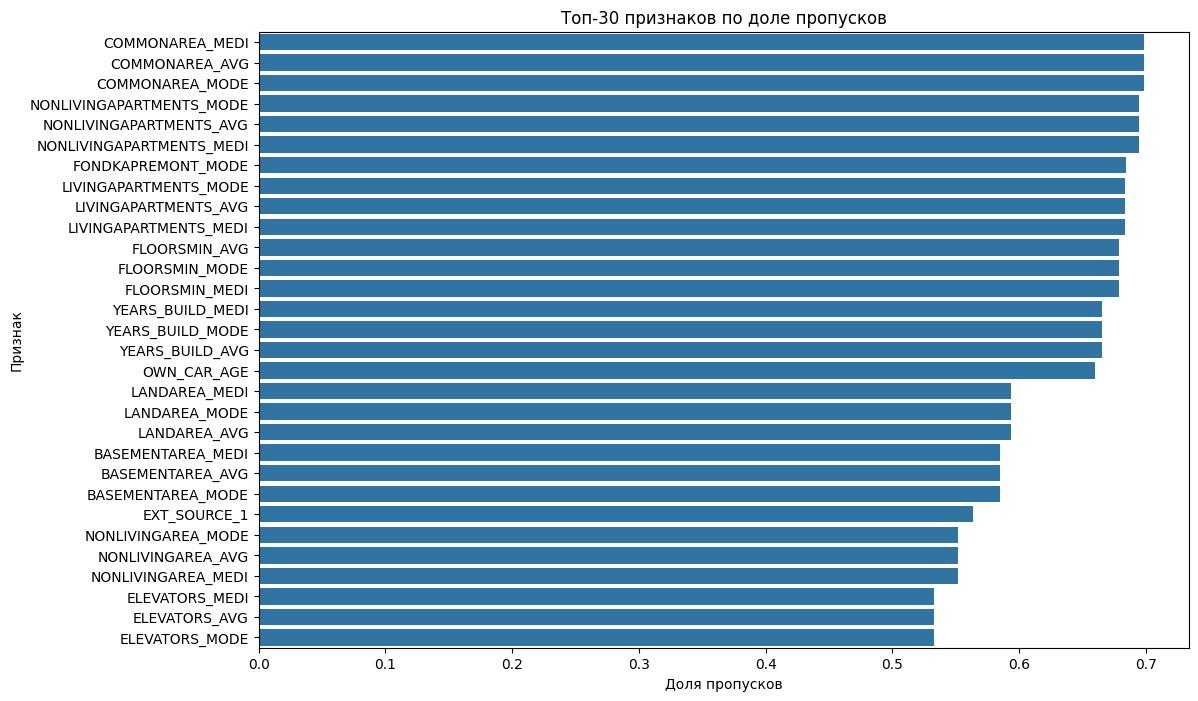

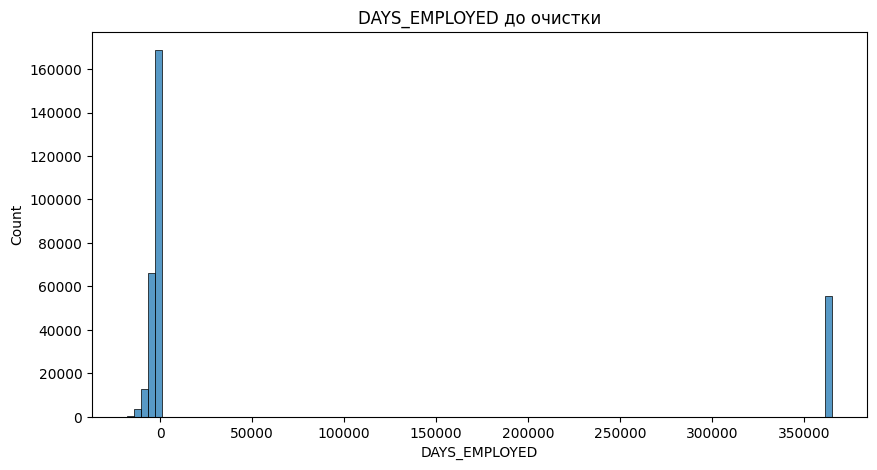

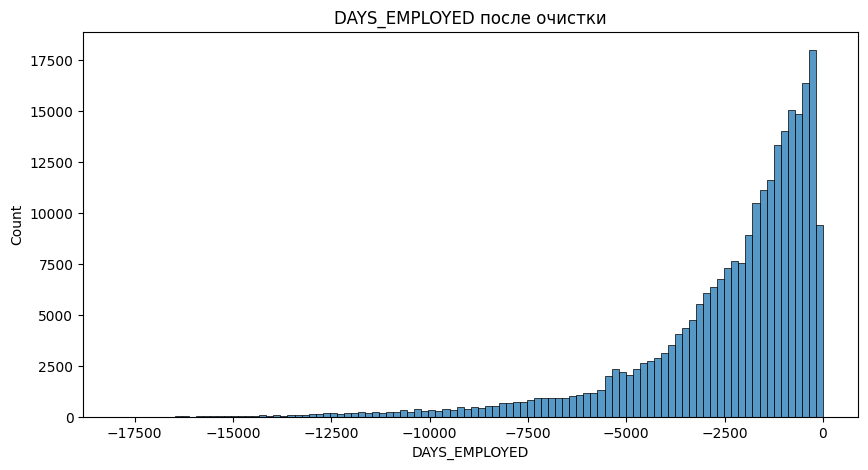

Форма: (307511, 122)


In [169]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = data.copy()

# анализ пропусков

missing_ratio = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
)

missing_df = pd.DataFrame({
    'feature': missing_ratio.index,
    'missing_ratio': missing_ratio.values
})

# визуализация пропусков

plt.figure(figsize=(12, 8))

sns.barplot(
    data=missing_df.head(30),
    x='missing_ratio',
    y='feature'
)

plt.title('Топ-30 признаков по доле пропусков')
plt.xlabel('Доля пропусков')
plt.ylabel('Признак')

plt.show()

# распределение DAYS_EMPLOYED до очистки

plt.figure(figsize=(10, 5))

sns.histplot(
    df['DAYS_EMPLOYED'],
    bins=100
)

plt.title('DAYS_EMPLOYED до очистки')

plt.show()

# очистка аномального значения

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].where(
    df['DAYS_EMPLOYED'] <= 0,
    np.nan
)

# распределение после очистки

plt.figure(figsize=(10, 5))

sns.histplot(
    df['DAYS_EMPLOYED'],
    bins=100
)

plt.title('DAYS_EMPLOYED после очистки')

plt.show()

# обновление основного датасета

data = df.copy()

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


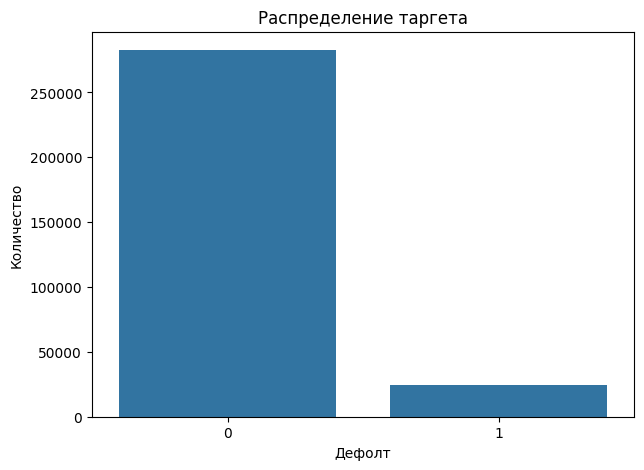

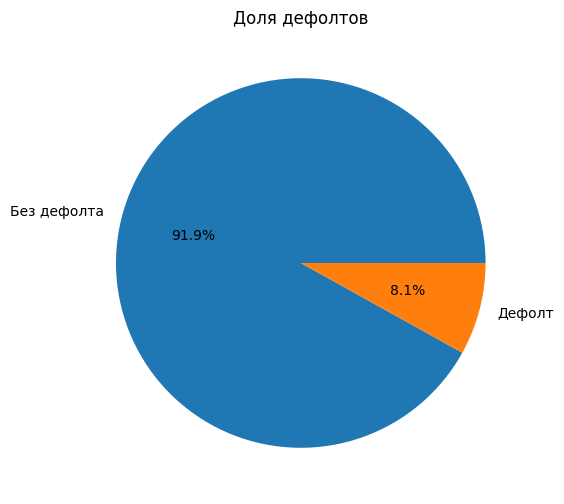

In [170]:
# анализ таргета

target_dist = (
    df['TARGET']
    .value_counts(normalize=True)
    .mul(100)
)

print(target_dist)

# распределение таргета

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='TARGET'
)

plt.title('Распределение таргета')
plt.xlabel('Дефолт')
plt.ylabel('Количество')

plt.show()

# доля дефолтов

plt.figure(figsize=(6, 6))

plt.pie(
    df['TARGET'].value_counts(),
    labels=['Без дефолта', 'Дефолт'],
    autopct='%1.1f%%'
)

plt.title('Доля дефолтов')

plt.show()


 AMT_CREDIT


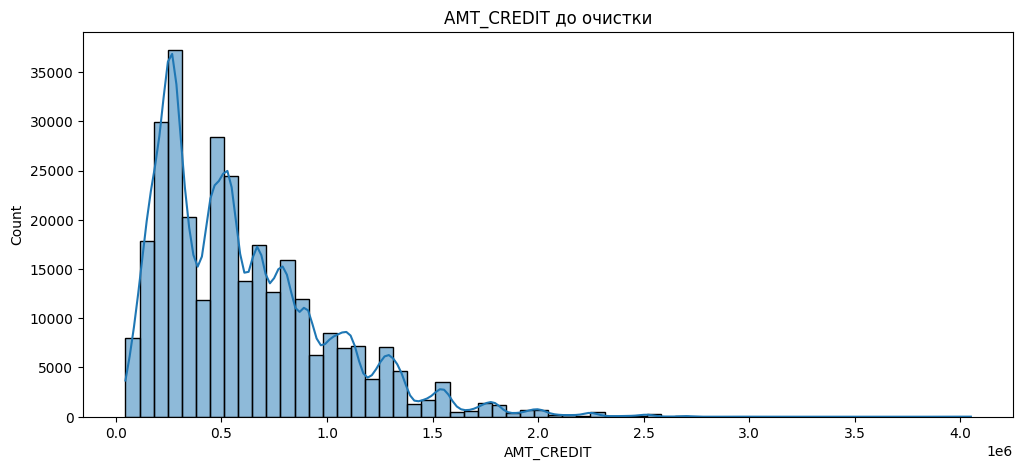

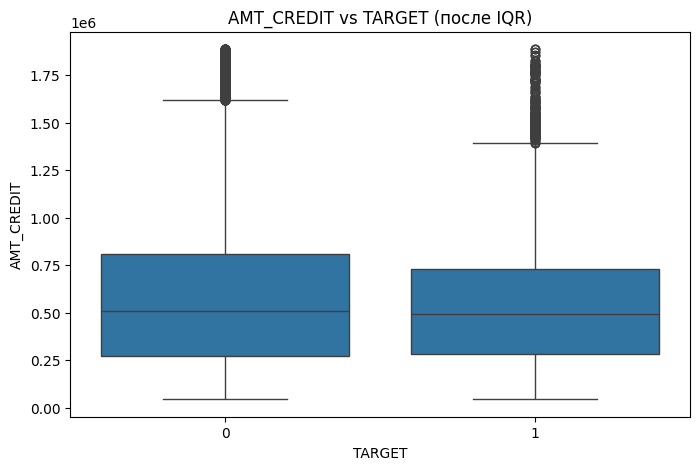

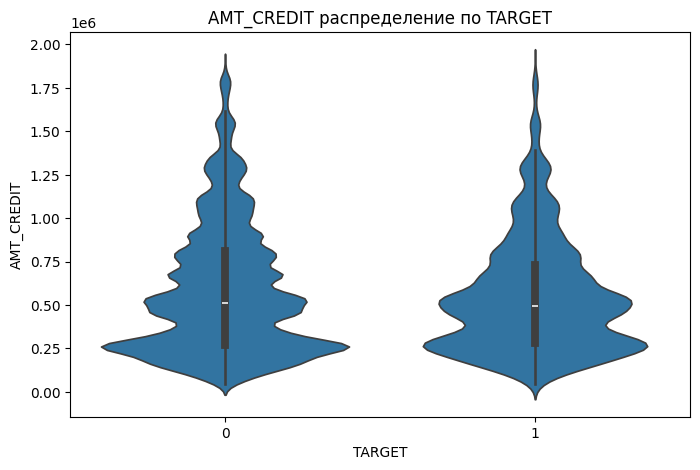


 AMT_ANNUITY


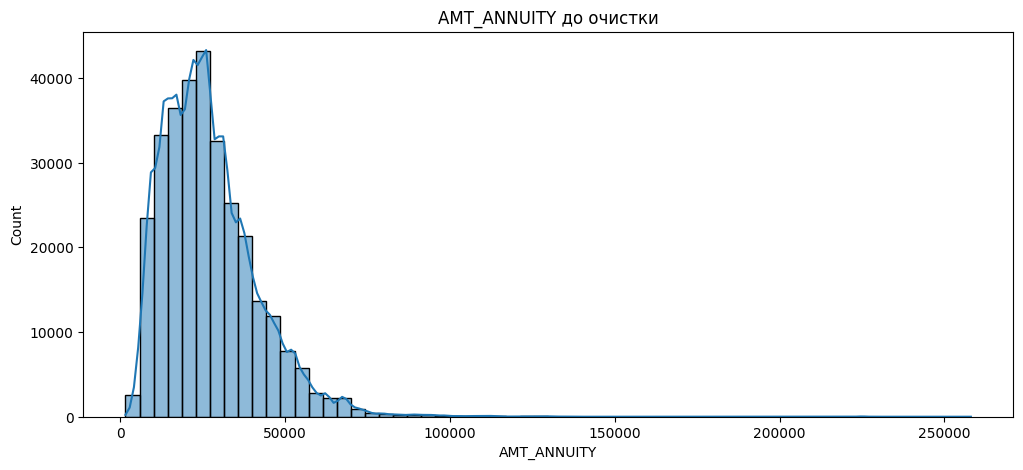

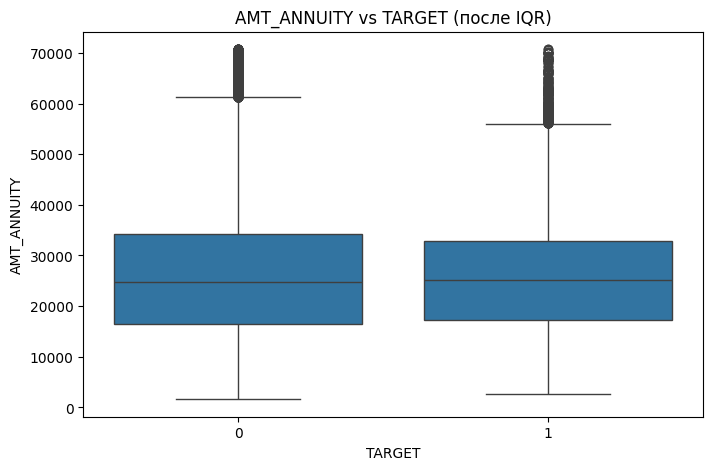

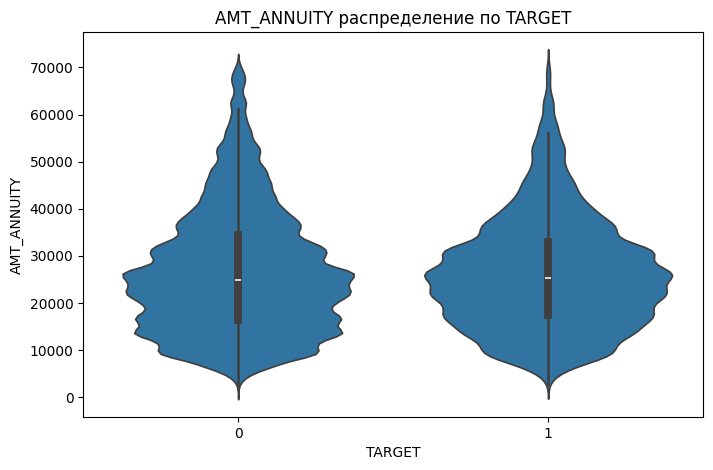


 AMT_GOODS_PRICE


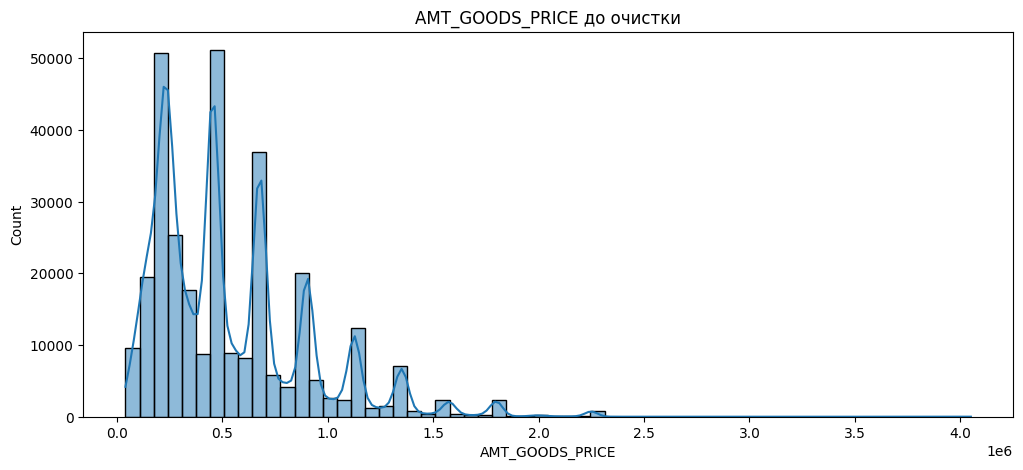

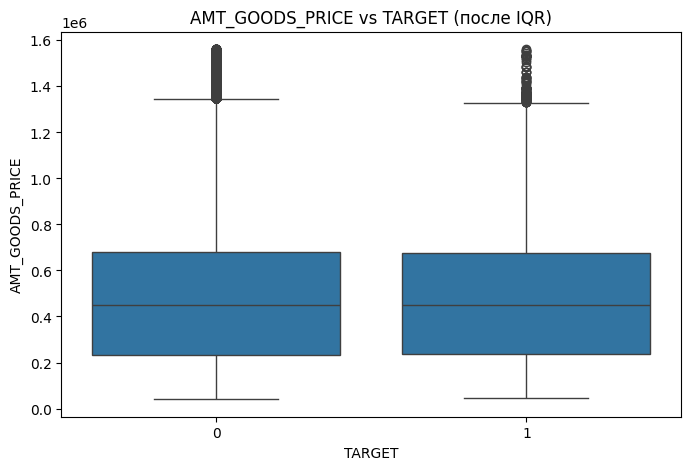

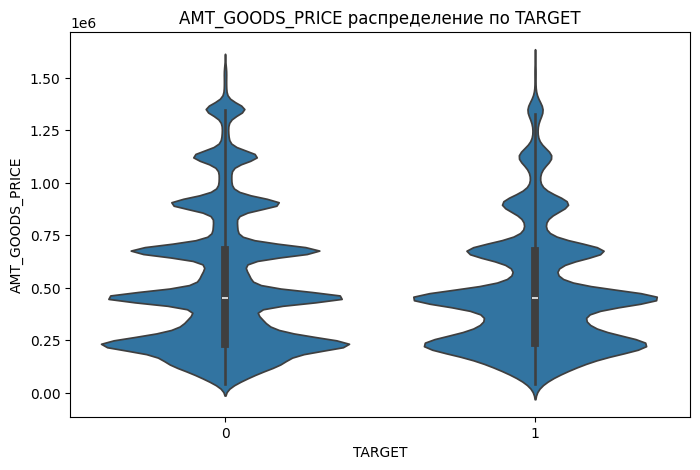

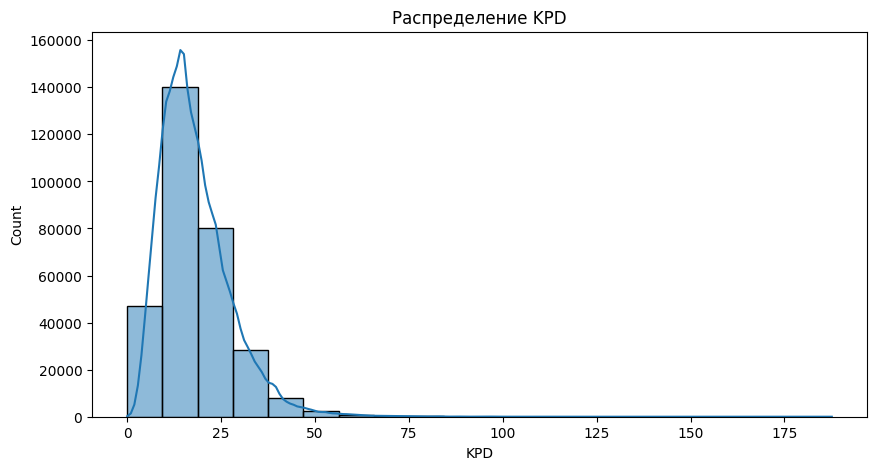

In [172]:
# финансовые признаки

financial_features = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE'
]

# отсечение по 2 IQR

def iqr_filter(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 2 * iqr
    upper = q3 + 2 * iqr

    return df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]


# визуализация распределений и зависимостей

for col in financial_features:

    print('\n', col)

    plt.figure(figsize=(12, 5))

    sns.histplot(
        df[col],
        kde=True,
        bins=60
    )

    plt.title(f'{col} до очистки')
    plt.show()

    temp_df = iqr_filter(df, col)

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=temp_df,
        x='TARGET',
        y=col
    )

    plt.title(f'{col} vs TARGET (после IQR)')
    plt.show()

    plt.figure(figsize=(8, 5))

    sns.violinplot(
        data=temp_df,
        x='TARGET',
        y=col
    )

    plt.title(f'{col} распределение по TARGET')
    plt.show()


# фича: платежная нагрузка

df['KPD'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'] * 100


plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='KPD',
    bins=20,
    kde=True
)

plt.title('Распределение KPD')
plt.show()

# обновление основного датасета

data = df.copy()

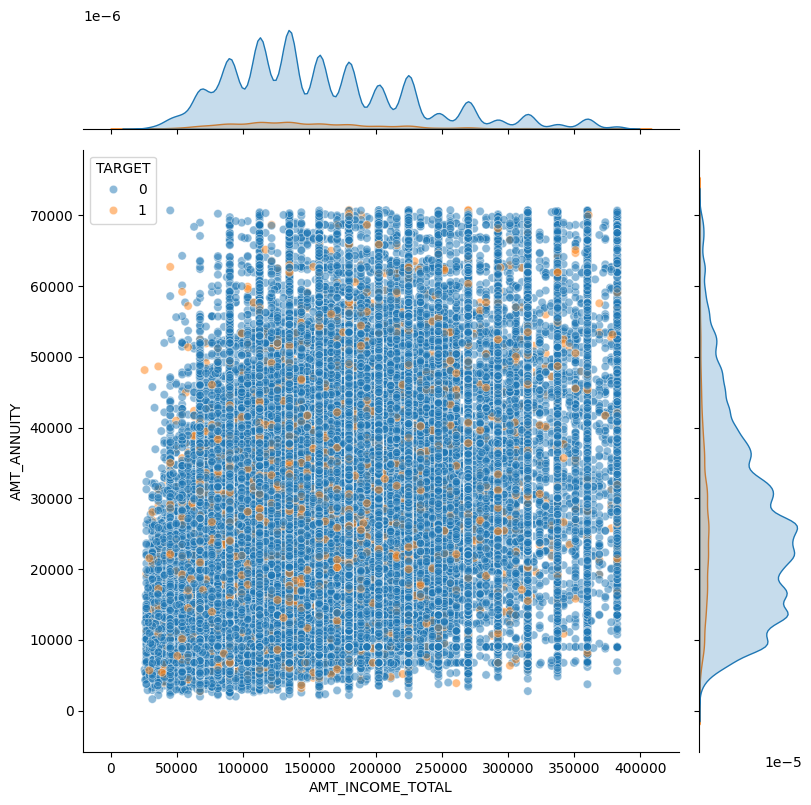

In [173]:
# совместное распределение дохода и платежа

joint_df = df[
    ['AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'TARGET']
].dropna()

# фильтрация выбросов только для визуализации
joint_df = iqr_filter(joint_df, 'AMT_ANNUITY')
joint_df = iqr_filter(joint_df, 'AMT_INCOME_TOTAL')

sns.jointplot(
    data=joint_df,
    x='AMT_INCOME_TOTAL',
    y='AMT_ANNUITY',
    hue='TARGET',
    height=8,
    alpha=0.5
)

plt.show()

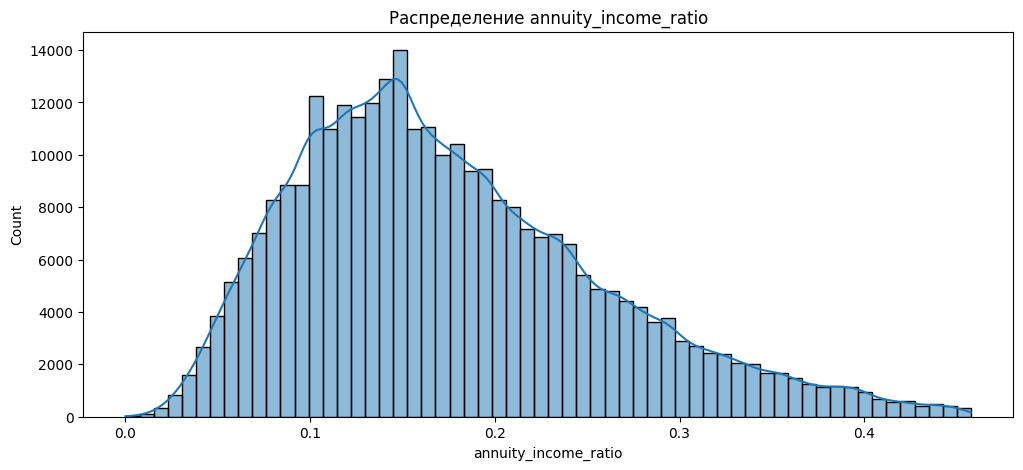

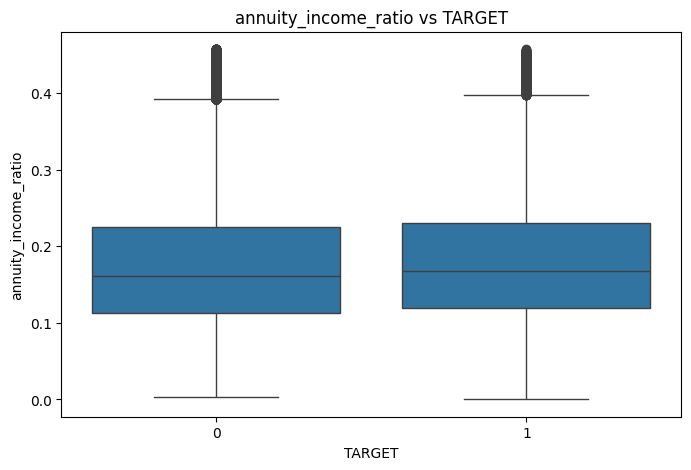

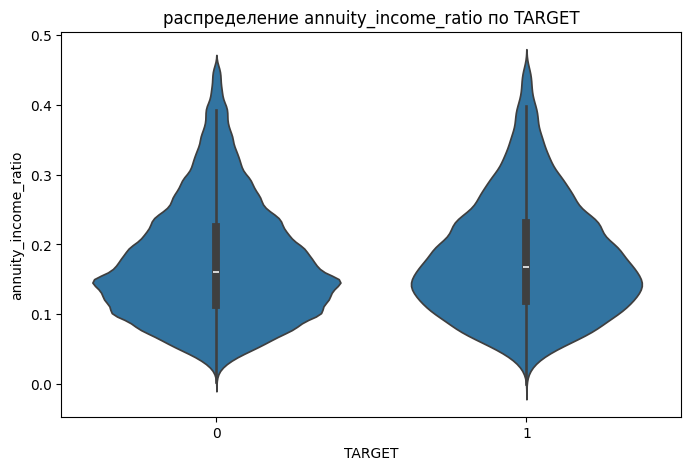

In [174]:
# фича-инженеринг

# ключевой признак проекта: нагрузка платежей на доход

df['annuity_income_ratio'] = (
    df['AMT_ANNUITY'] /
    df['AMT_INCOME_TOTAL']
)

# данные для анализа распределения
ratio_df = df[
    ['annuity_income_ratio', 'TARGET']
].dropna()

# очистка только для визуализации
ratio_df = iqr_filter(
    ratio_df,
    'annuity_income_ratio'
)

# распределение признака

plt.figure(figsize=(12, 5))

sns.histplot(
    ratio_df['annuity_income_ratio'],
    bins=60,
    kde=True
)

plt.title('Распределение annuity_income_ratio')
plt.show()

# связь с таргетом

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=ratio_df,
    x='TARGET',
    y='annuity_income_ratio'
)

plt.title('annuity_income_ratio vs TARGET')
plt.show()

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=ratio_df,
    x='TARGET',
    y='annuity_income_ratio'
)

plt.title('распределение annuity_income_ratio по TARGET')
plt.show()

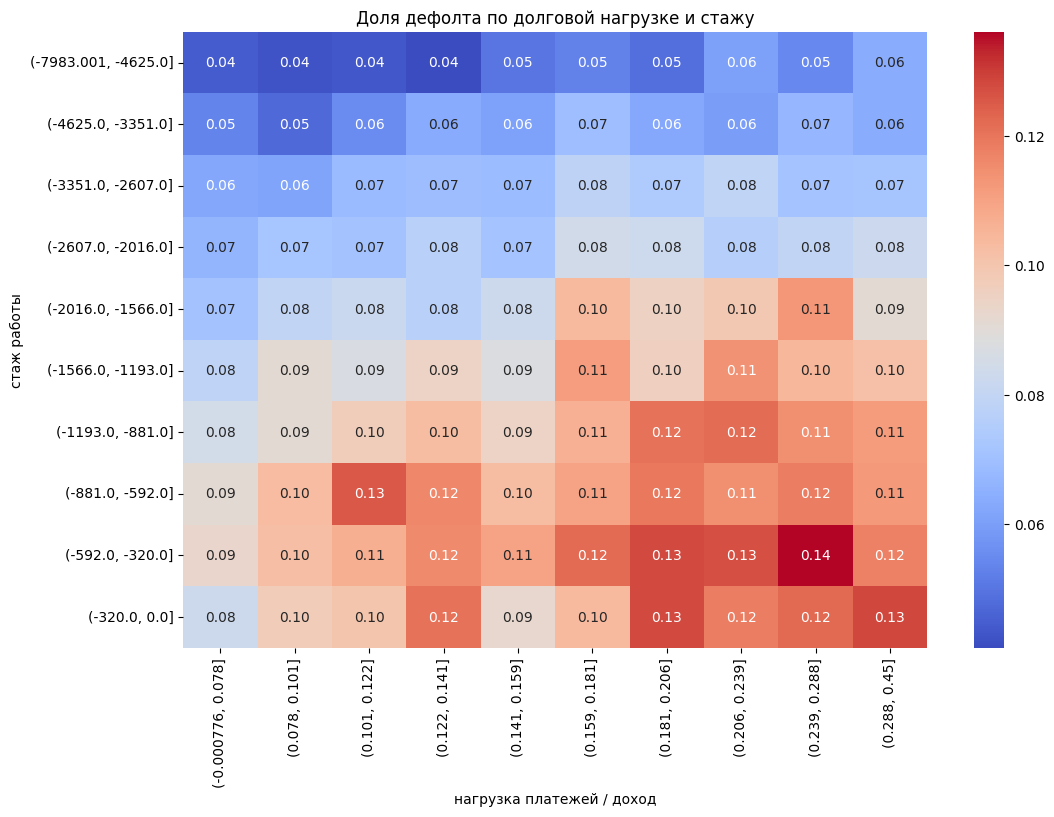

In [176]:
# тепловая карта дефолта

heatmap_df = df[
    [
        'AMT_ANNUITY',
        'AMT_INCOME_TOTAL',
        'DAYS_EMPLOYED',
        'TARGET'
    ]
].dropna()

# ключевой признак

heatmap_df['annuity_income_ratio'] = (
    heatmap_df['AMT_ANNUITY'] /
    heatmap_df['AMT_INCOME_TOTAL'].replace(0, np.nan)
)

# очистка выбросов (только для анализа)

heatmap_df = iqr_filter(
    heatmap_df,
    'annuity_income_ratio'
)

heatmap_df = iqr_filter(
    heatmap_df,
    'DAYS_EMPLOYED'
)

# биннинг признаков

heatmap_df['ratio_bin'] = pd.qcut(
    heatmap_df['annuity_income_ratio'],
    q=10,
    duplicates='drop'
)

heatmap_df['employment_bin'] = pd.qcut(
    heatmap_df['DAYS_EMPLOYED'],
    q=10,
    duplicates='drop'
)

# расчет среднего дефолта

pivot_table = (
    heatmap_df
    .groupby(['employment_bin', 'ratio_bin'])['TARGET']
    .mean()
    .unstack()
)

# визуализация

plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Доля дефолта по долговой нагрузке и стажу')
plt.xlabel('нагрузка платежей / доход')
plt.ylabel('стаж работы')

plt.show()

# учтем очень слабые связи


 NAME_INCOME_TYPE


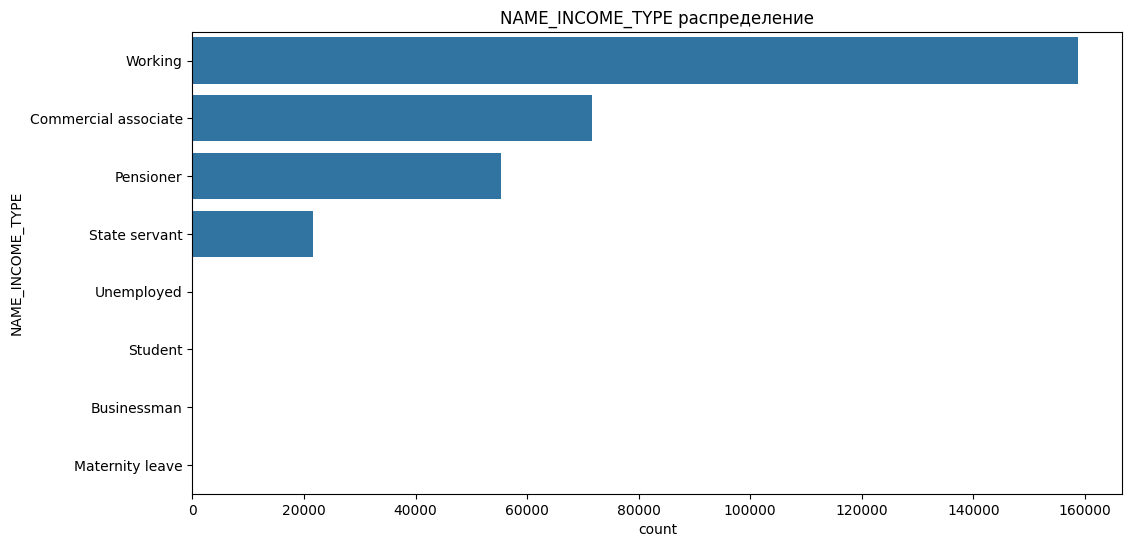

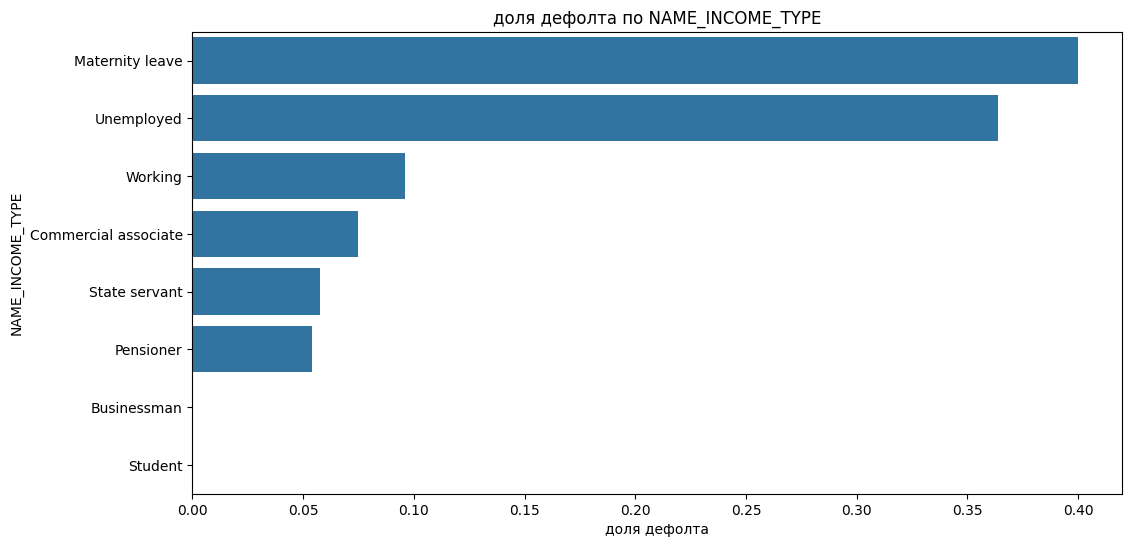


 NAME_EDUCATION_TYPE


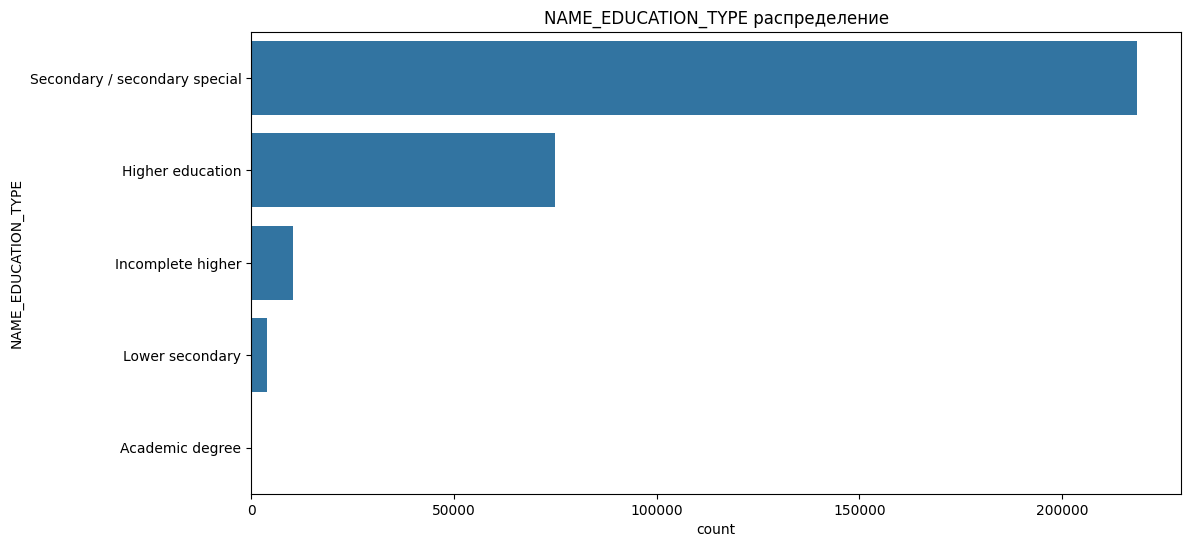

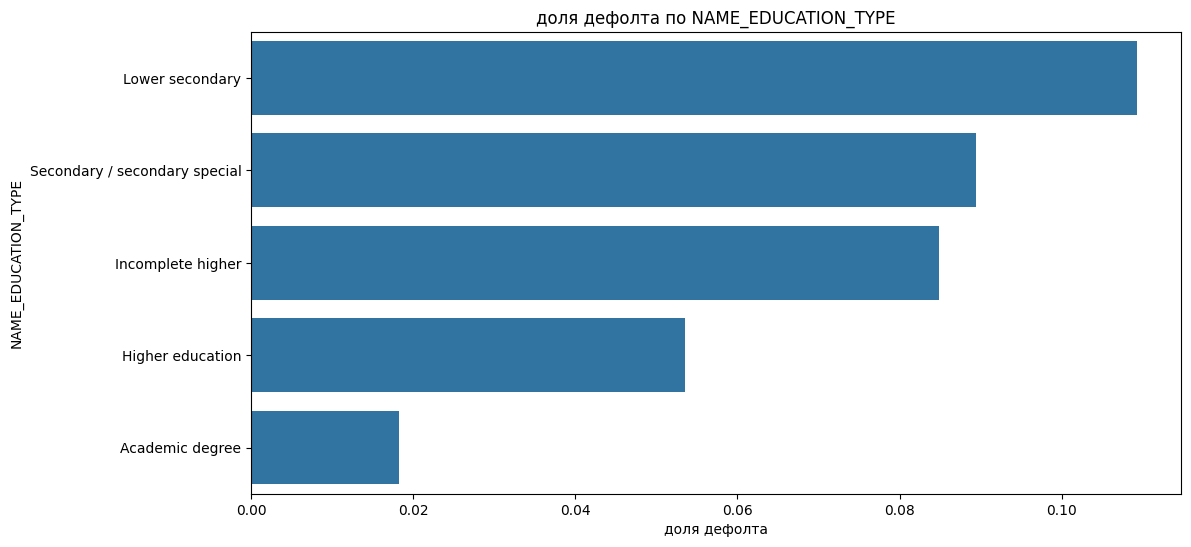


 OCCUPATION_TYPE


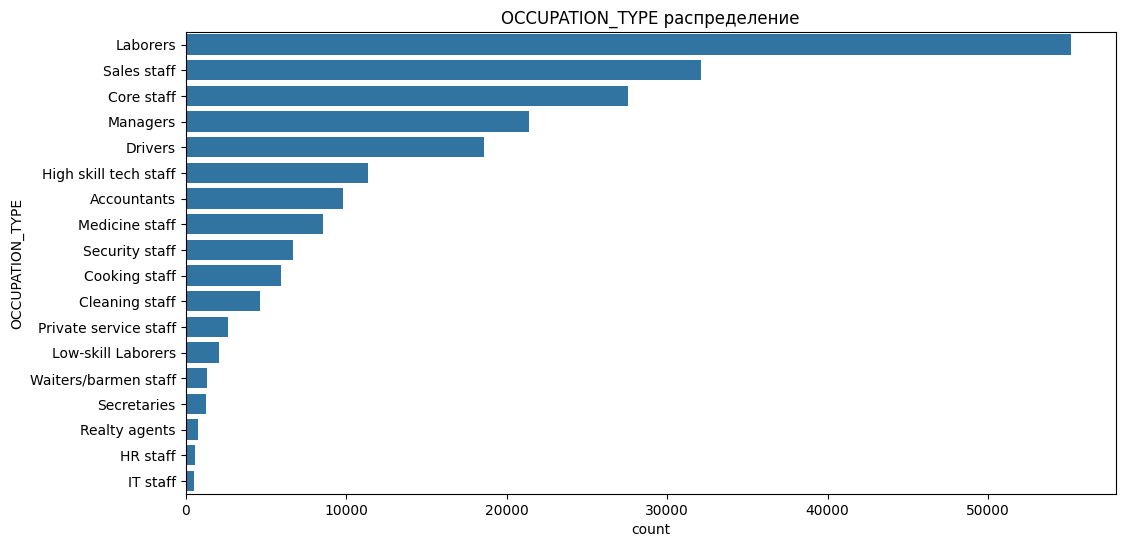

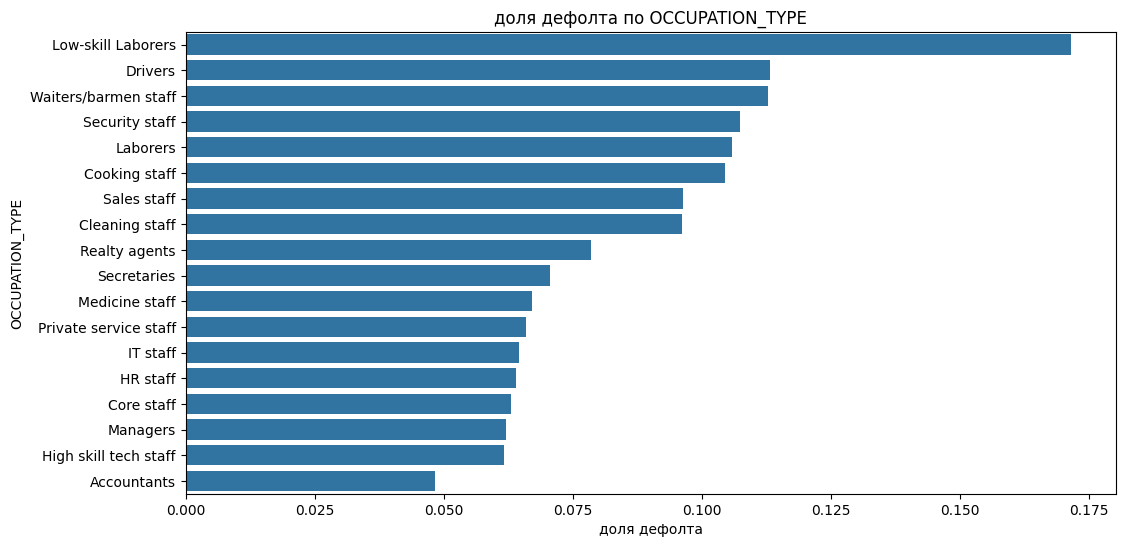


 NAME_FAMILY_STATUS


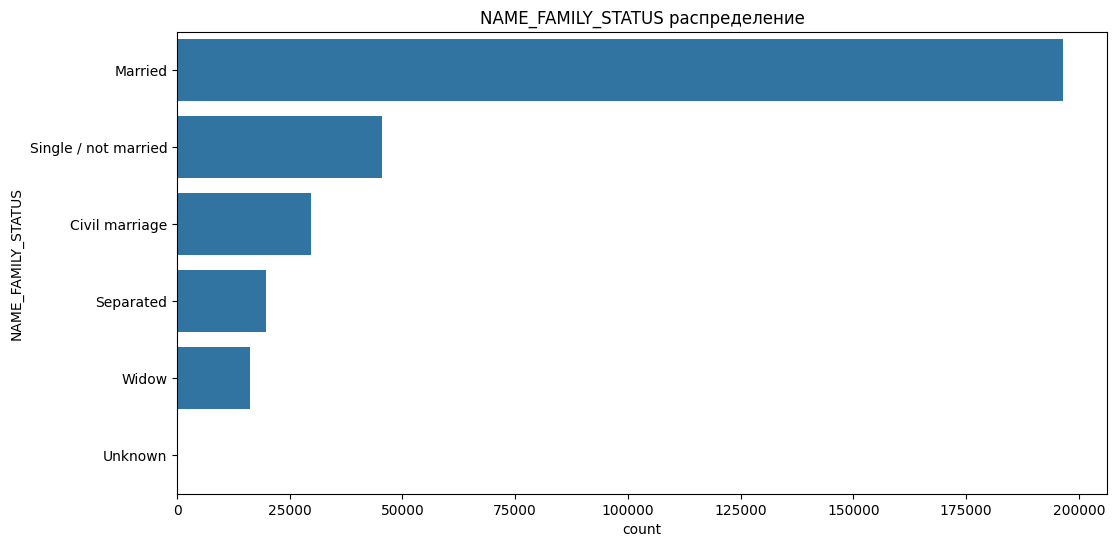

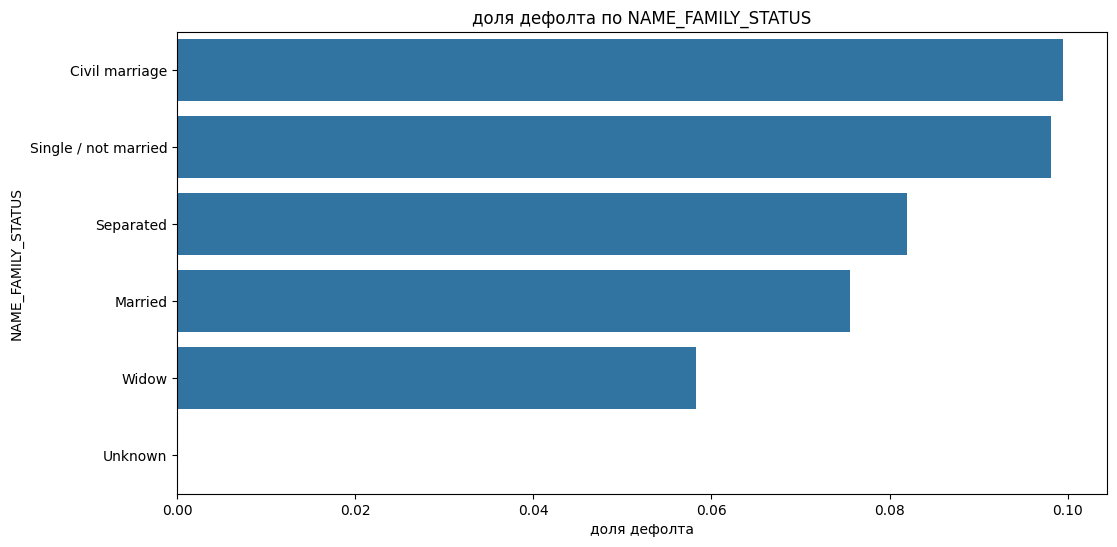


 CODE_GENDER


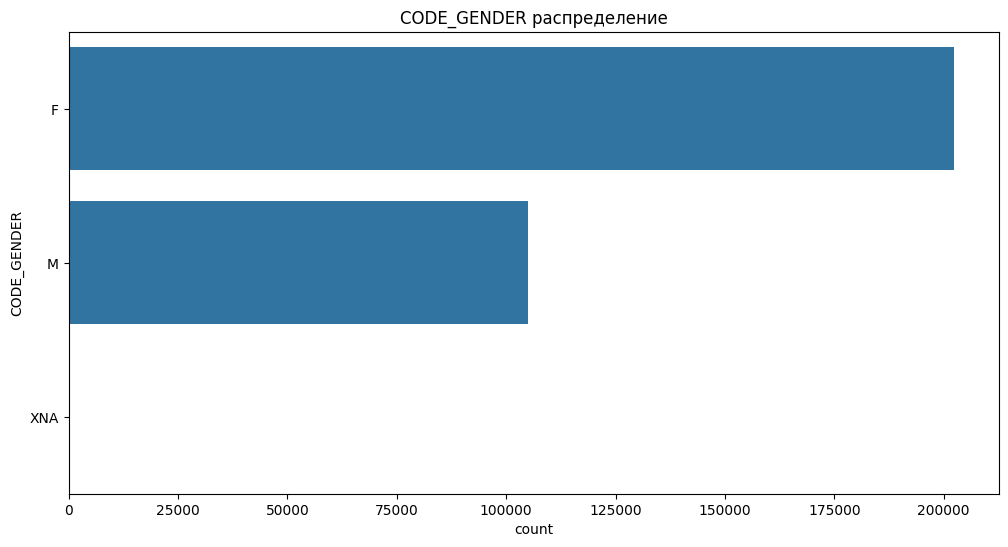

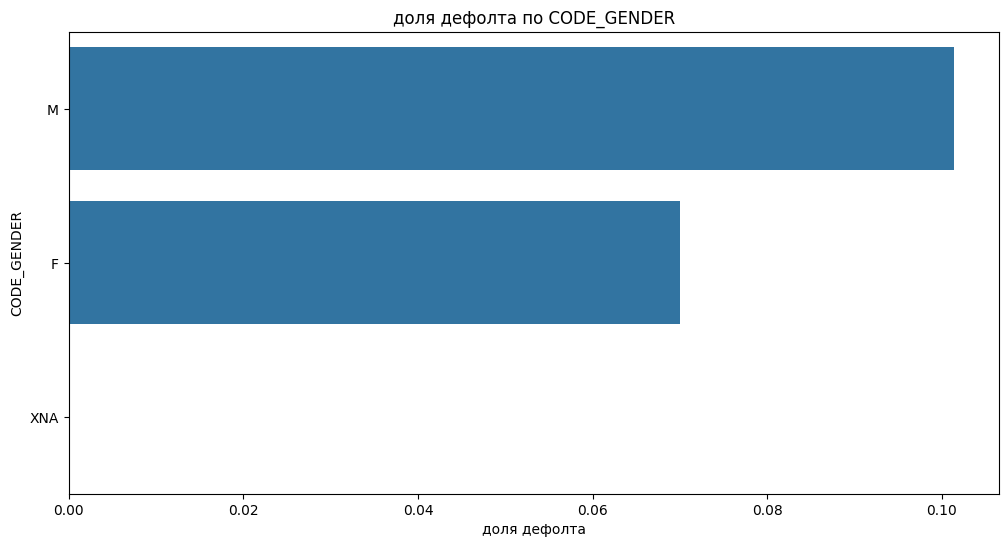

In [178]:
# анализ категориальных признаков

categorical_features = [
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'OCCUPATION_TYPE',
    'NAME_FAMILY_STATUS',
    'CODE_GENDER'
]

for col in categorical_features:

    print('\n', col)

    # распределение категорий

    plt.figure(figsize=(12, 6))

    order = (
        df[col]
        .value_counts()
        .index
    )

    sns.countplot(
        data=df,
        y=col,
        order=order
    )

    plt.title(f'{col} распределение')
    plt.show()

    # риск дефолта по категориям

    target_rate = (
        df
        .groupby(col)['TARGET']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=target_rate,
        x='TARGET',
        y=col
    )

    plt.title(f'доля дефолта по {col}')
    plt.xlabel('доля дефолта')
    plt.show()

#по ряду категориальных признаков намного более значимые различия. это можно объяснить тем, что категориальные признаки менее подвержены влиянию страны проживания (суммы количественных признаков каждая в своей валюте, из-за чего закономерности не видно).

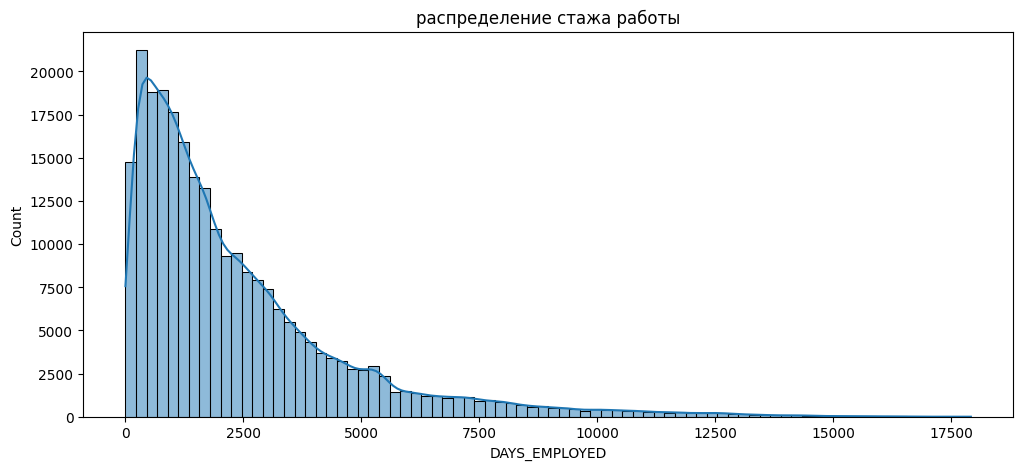

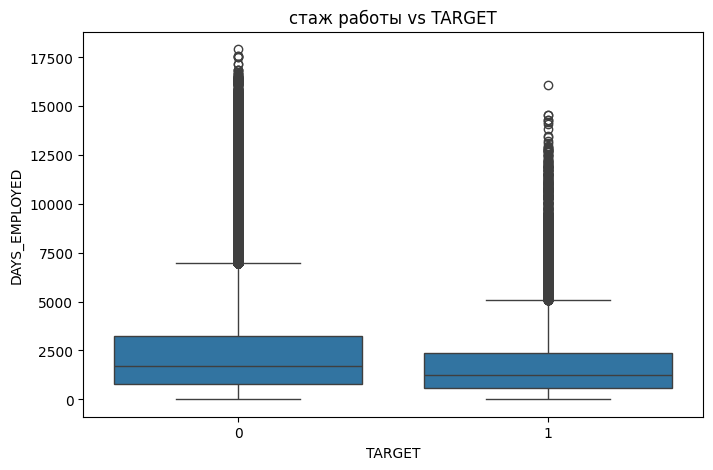

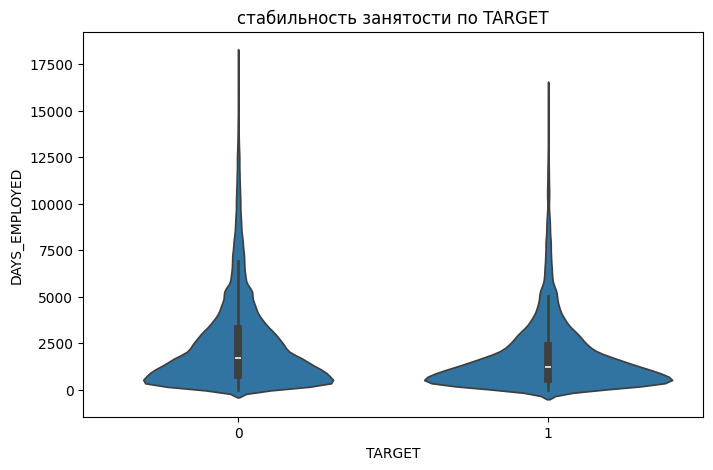

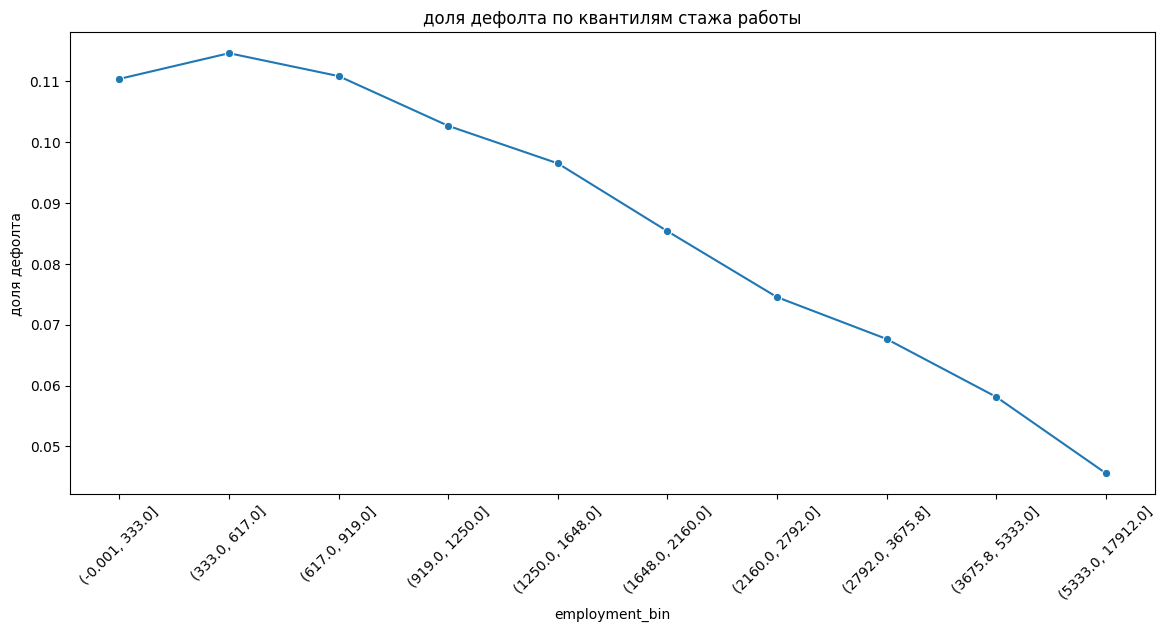

In [179]:
# стабильность занятости

employment_df = df.copy()

# восстановление смысла признака (в датасете он отрицательный)
employment_df['DAYS_EMPLOYED'] = employment_df['DAYS_EMPLOYED'].mul(-1)

# удаление пропусков
employment_df = employment_df[
    employment_df['DAYS_EMPLOYED'].notna()
]

# распределение

plt.figure(figsize=(12, 5))

sns.histplot(
    employment_df['DAYS_EMPLOYED'],
    bins=80,
    kde=True
)

plt.title('распределение стажа работы')
plt.show()

# связь с таргетом

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=employment_df,
    x='TARGET',
    y='DAYS_EMPLOYED'
)

plt.title('стаж работы vs TARGET')
plt.show()

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=employment_df,
    x='TARGET',
    y='DAYS_EMPLOYED'
)

plt.title('стабильность занятости по TARGET')
plt.show()

# бинирование

employment_df['employment_bin'] = pd.qcut(
    employment_df['DAYS_EMPLOYED'],
    q=10,
    duplicates='drop'
)

risk_by_employment = (
    employment_df
    .groupby('employment_bin', observed=False)['TARGET']
    .mean()
    .reset_index()
)

# преобразование для графика
risk_by_employment['employment_bin'] = (
    risk_by_employment['employment_bin'].astype(str)
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=risk_by_employment,
    x='employment_bin',
    y='TARGET',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('доля дефолта по квантилям стажа работы')
plt.ylabel('доля дефолта')

plt.show()

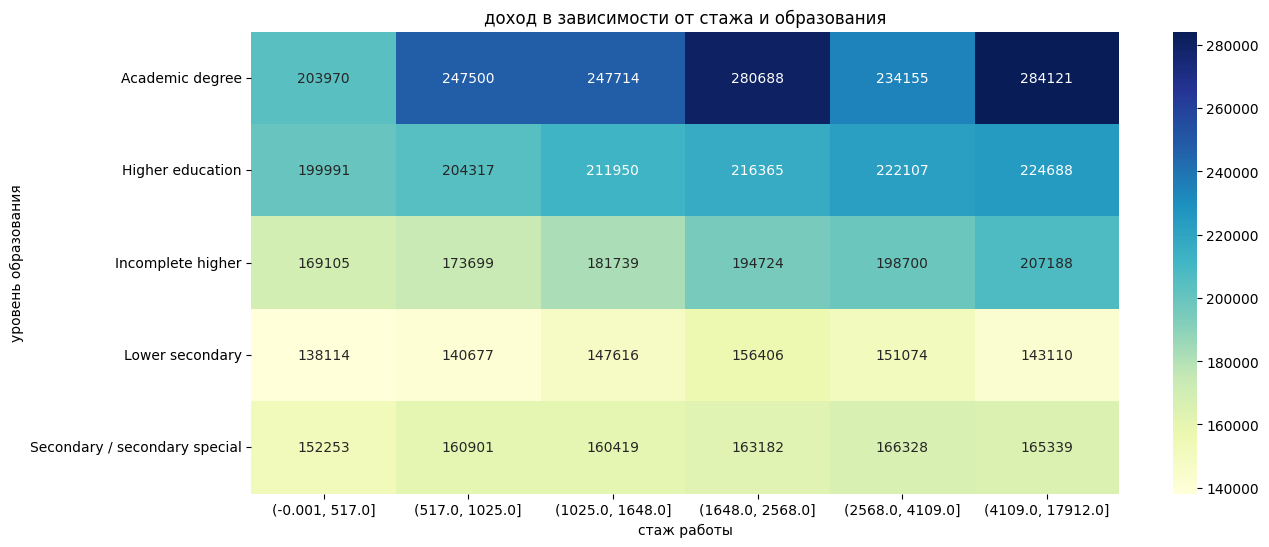

In [181]:
# зависимость дохода от стажа и образования

heatmap_df = df.copy()

heatmap_df = heatmap_df[
    [
        'DAYS_EMPLOYED',
        'AMT_INCOME_TOTAL',
        'NAME_EDUCATION_TYPE'
    ]
].dropna()

# абсолютный стаж
heatmap_df['DAYS_EMPLOYED'] = heatmap_df['DAYS_EMPLOYED'].abs()

# бинирование стажа
heatmap_df['employment_bin'] = pd.qcut(
    heatmap_df['DAYS_EMPLOYED'],
    q=6,
    duplicates='drop'
)

# сводная таблица
pivot_table = (
    heatmap_df
    .groupby(
        ['NAME_EDUCATION_TYPE', 'employment_bin']
    )['AMT_INCOME_TOTAL']
    .mean()
    .unstack()
)

# визуализация

plt.figure(figsize=(14, 6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('доход в зависимости от стажа и образования')
plt.xlabel('стаж работы')
plt.ylabel('уровень образования')

plt.show()

In [143]:
#теперь в целом можно сформулировать гипотезу (ясны потенциальные связи и их порядок с таргетом): высокий коэффициент долговой нагрузки сильнее влияет на вероятность дефолта при короткой / нестабильной занятости.


0:	test: 0.7023501	best: 0.7023501 (0)	total: 88ms	remaining: 1m 1s
100:	test: 0.7413636	best: 0.7413636 (100)	total: 7.31s	remaining: 43.3s
200:	test: 0.7474226	best: 0.7474226 (200)	total: 14.5s	remaining: 36s
300:	test: 0.7502393	best: 0.7502393 (300)	total: 21.6s	remaining: 28.7s
400:	test: 0.7520234	best: 0.7520234 (400)	total: 28.8s	remaining: 21.4s
500:	test: 0.7541408	best: 0.7541408 (500)	total: 36.8s	remaining: 14.6s
600:	test: 0.7553583	best: 0.7553583 (600)	total: 44.9s	remaining: 7.4s
699:	test: 0.7561816	best: 0.7561816 (699)	total: 53.2s	remaining: 0us

bestTest = 0.7561815584
bestIteration = 699


CatBoost модель

ROC AUC: 0.7561815584324628
Precision: 0.17925386715195632
Recall: 0.6348439073514602
F1: 0.2795689387555989
              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56538
           1       0.18      0.63      0.28      4965

    accuracy                           0.74     61503
   macro avg       0.57      0.69  

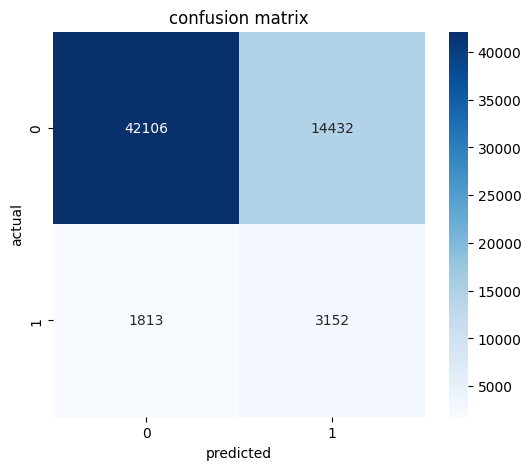

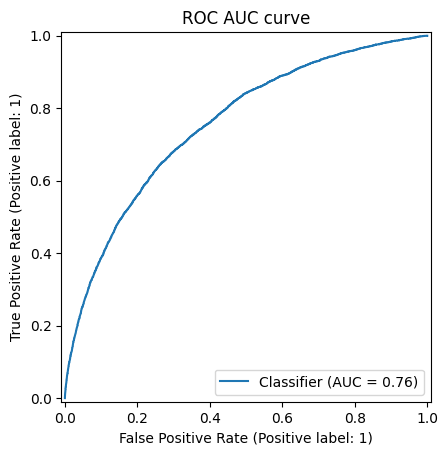

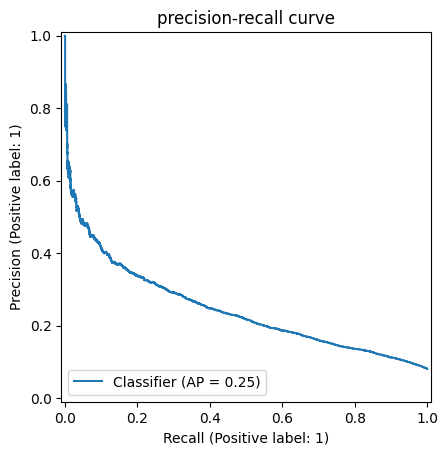

In [182]:
# подготовка

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_score,
    recall_score,
    f1_score
)

from catboost import CatBoostClassifier

# копия датасета

model_data = df.copy()

# фичи проекта

model_data['annuity_income_ratio'] = (
    model_data['AMT_ANNUITY'] /
    model_data['AMT_INCOME_TOTAL'].replace(0, np.nan)
)

model_data['employment_age_ratio'] = (
    model_data['DAYS_EMPLOYED'] /
    model_data['DAYS_BIRTH']
)

# числовые признаки

numeric_features = [
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_GOODS_PRICE',
    'DAYS_EMPLOYED',
    'DAYS_BIRTH',
    'annuity_income_ratio',
    'employment_age_ratio',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

# категориальные признаки

categorical_features = [
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'OCCUPATION_TYPE',
    'CODE_GENDER'
]

all_features = numeric_features + categorical_features

# обработка категориальных

for col in categorical_features:
    model_data[col] = (
        model_data[col]
        .fillna('missing')
        .astype(str)
    )

# очистка таргета

model_data = model_data[
    model_data['TARGET'].notna()
]

# финальный датасет

model_df = model_data[all_features + ['TARGET']]

# train/test split

X = model_df[all_features]
y = model_df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# индексы категориальных признаков

cat_features_index = [
    X.columns.get_loc(col)
    for col in categorical_features
]

# модель CatBoost

cat_model = CatBoostClassifier(
    iterations=700,
    learning_rate=0.03,
    depth=6,
    eval_metric='AUC',
    loss_function='Logloss',
    l2_leaf_reg=8,
    class_weights=[1, 10],
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features_index,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# предсказания

cat_pred_proba = cat_model.predict_proba(X_test)[:, 1]

cat_pred = (cat_pred_proba > 0.5).astype(int)

# метрики

print('\nCatBoost модель\n')

print('ROC AUC:', roc_auc_score(y_test, cat_pred_proba))
print('Precision:', precision_score(y_test, cat_pred))
print('Recall:', recall_score(y_test, cat_pred))
print('F1:', f1_score(y_test, cat_pred))

print(
    classification_report(y_test, cat_pred)
)

# confusion matrix

cm = confusion_matrix(y_test, cat_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

# ROC curve

RocCurveDisplay.from_predictions(
    y_test,
    cat_pred_proba
)

plt.title('ROC AUC curve')
plt.show()

# precision-recall curve

PrecisionRecallDisplay.from_predictions(
    y_test,
    cat_pred_proba
)

plt.title('precision-recall curve')
plt.show()

In [183]:
# итак смотрим на метрики: ROC-AUC - хороший (более 0.75), с precision=0: 0,96; c precision=1: 0,18. Такой низкий уровень precision объясняется тем, что модель очень агрессивна в поиске дефолтов. это может быть полезно, если цель модели - не пропустить дефолты любой ценой. с другой стороны следуя этой модели бизнес может недополучить прибыль. precision в этой случае важнее recall